# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Viola Adhanty Zahra
- **Email:** viola06zahra@gmail.com
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren jumlah penyewaan sepeda berdasarkan bulan selama periode 2011-2012 untuk mengetahui bulan dengan tingkat permintaan tertinggi?
- **Pertanyaan 2:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

#### Load df ...

In [14]:
df = pd.read_csv('/content/day.csv')

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset Bike Sharing berhasil dimuat menggunakan pandas.
- Dataset terdiri dari data penyewaan sepeda berdasarkan waktu, musim, cuaca, dan jumlah pengguna.

### Assessing Data

#### Identifying ... problem

In [15]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Melakukan pengecekan missing value pada dataset.
- Melakukan pengecekan duplicate data.
- Melakukan pengecekan tipe data dan nilai statistik untuk menemukan kemungkinan outlier.

**Insight:** Assessing
- Dataset tidak memiliki missing value.
- Dataset perlu dilakukan pengecekan duplicate data untuk memastikan kualitas data.
- Beberapa kolom numerik memiliki rentang nilai yang berbeda sehingga perlu diperiksa.

### Cleaning Data

#### Fixing ... problem

In [16]:
df.drop_duplicates(inplace=True)

df['dteday'] = pd.to_datetime(df['dteday'])

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Data duplikat telah dihapus.
- Kolom tanggal telah diubah menjadi format datetime agar dapat digunakan untuk analisis waktu.

## Exploratory Data Analysis (EDA)

### Analisis Tren Penyewaan Sepeda

In [17]:
df['month'] = df['dteday'].dt.month
monthly = df.groupby('month')['cnt'].mean()

monthly

,cnt
month,
1,2176.338710
2,2655.298246
3,3692.258065
4,4484.900000
5,5349.774194
6,5772.366667
7,5563.677419
8,5664.419355
9,5766.516667


**Insight:** (Opsional)
- Jumlah penyewaan sepeda memiliki pola berbeda pada setiap bulan.
- Bulan dengan nilai rental tertinggi menunjukkan periode permintaan tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda berdasarkan bulan?

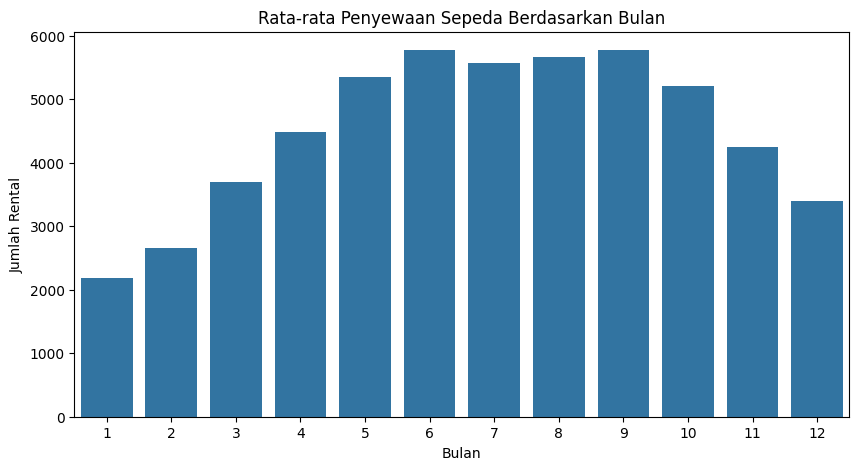

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly.index,
    y=monthly.values
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Rental")

plt.show()

### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

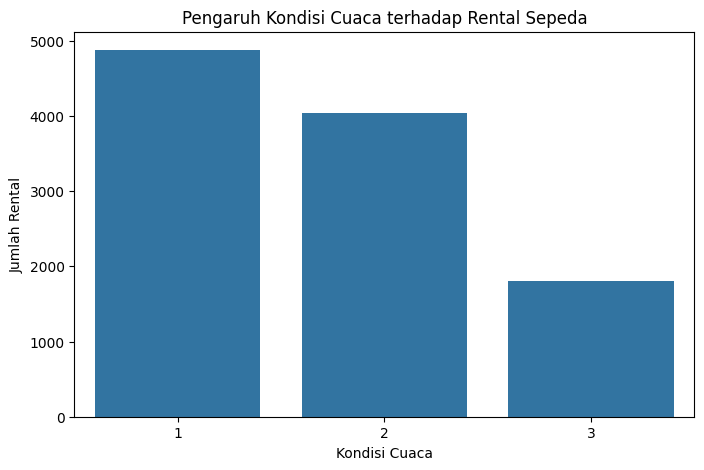

In [19]:
weather = df.groupby('weathersit')['cnt'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=weather.index,
    y=weather.values
)

plt.title("Pengaruh Kondisi Cuaca terhadap Rental Sepeda")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Rental")

plt.show()

**Insight:** (Opsional)
- Grafik pertama menunjukkan pola permintaan penyewaan berdasarkan bulan.
- Grafik kedua menunjukkan perubahan jumlah penyewaan berdasarkan kondisi cuaca.

## Analisis Hari Kerja

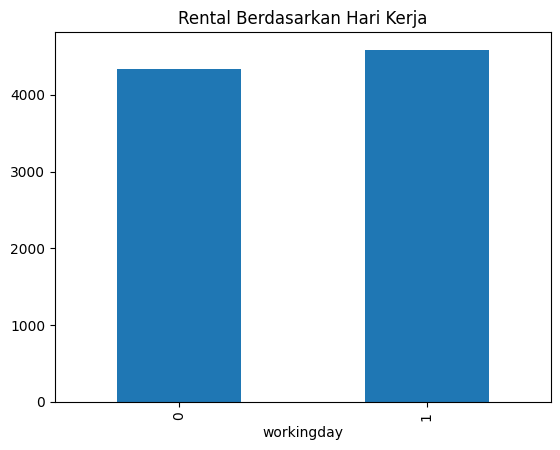

In [20]:
workingday = df.groupby('workingday')['cnt'].mean()

workingday
workingday.plot(kind='bar')

plt.title("Rental Berdasarkan Hari Kerja")

plt.show()

**Insight:** (Opsional)
- Perbedaan jumlah rental terlihat antara hari kerja dan hari libur.
- Informasi ini dapat digunakan untuk strategi operasional.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis, jumlah penyewaan sepeda mengalami perubahan setiap bulan. Periode dengan jumlah rental tertinggi menunjukkan waktu dengan permintaan tinggi sehingga perusahaan perlu meningkatkan ketersediaan sepeda.
- **Conclusion pertanyaan 2:** Berdasarkan hasil analisis, kondisi cuaca memiliki hubungan dengan jumlah penyewaan sepeda. Cuaca yang kurang mendukung dapat menyebabkan penurunan jumlah pengguna.

**Rekomendasi Action Item:**
- Menambah jumlah sepeda dan meningkatkan kesiapan operasional pada bulan dengan permintaan tinggi.
- Membuat strategi promosi atau penyesuaian layanan ketika kondisi cuaca kurang mendukung.